<a href="https://colab.research.google.com/github/pariiii-khandal/EDA_PROJECT/blob/main/25BDS0197_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- BLOCK A: LOADING & PREPROCESSING ---
Number of samples: 10000
Number of classes: 10
Original image dimensions: 28 x 28 pixels (Flattened into 784 features)


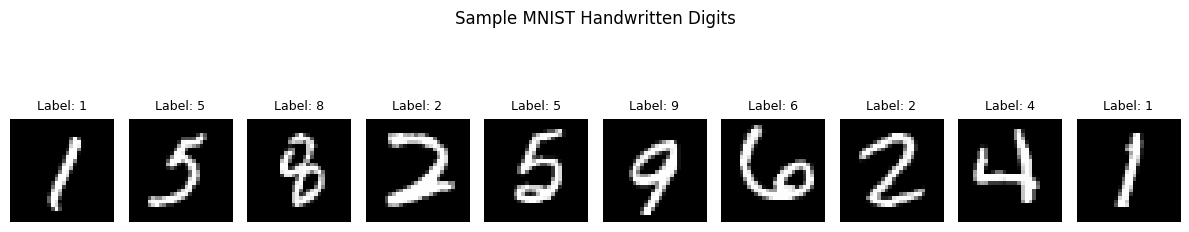

Data normalized successfully.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("--- BLOCK A: LOADING & PREPROCESSING ---")

# 1. Fetch the dataset from OpenML
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data.to_numpy(), mnist.target.to_numpy().astype(int)

# 2. Downsample to 10,000 instances for performance efficiency
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=10000, random_state=42, stratify=y)

# Display Dataset Information
print(f"Number of samples: {X_sub.shape[0]}")
print(f"Number of classes: {len(np.unique(y_sub))}")
print(f"Original image dimensions: 28 x 28 pixels (Flattened into {X_sub.shape[1]} features)")

# 3. Visualize 10 sample images
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_sub[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_sub[i]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample MNIST Handwritten Digits")
plt.tight_layout()
plt.show()

# 4. Normalize pixel values to range [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_sub)
print("Data normalized successfully.")



--- BLOCK B: PRINCIPAL COMPONENT ANALYSIS ---
Components required for 90% variance: 86
Components required for 95% variance: 151
Components required for 99% variance: 327


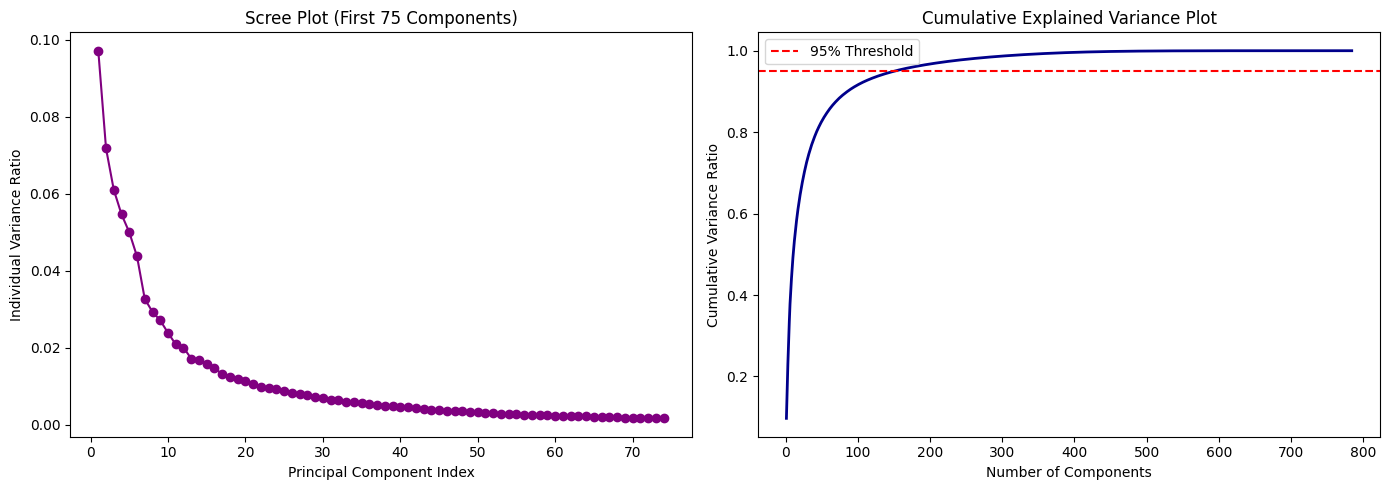

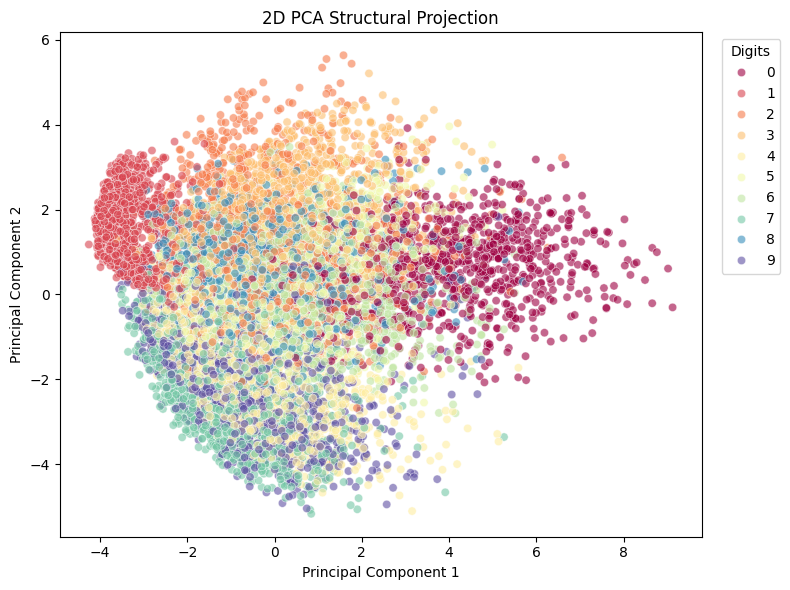

In [2]:
import seaborn as sns
from sklearn.decomposition import PCA

print("\n--- BLOCK B: PRINCIPAL COMPONENT ANALYSIS ---")

# 1. Fit full PCA to find variance ratios
pca_full = PCA()
pca_full.fit(X_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 2. Calculate components needed for variance milestones
n_90 = np.argmax(cum_variance >= 0.90) + 1
n_95 = np.argmax(cum_variance >= 0.95) + 1
n_99 = np.argmax(cum_variance >= 0.99) + 1

print(f"Components required for 90% variance: {n_90}")
print(f"Components required for 95% variance: {n_95}")
print(f"Components required for 99% variance: {n_99}")

# 3. Generate Scree and Cumulative Plots
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 75), pca_full.explained_variance_ratio_[:74], marker='o', color='purple')
plt.title("Scree Plot (First 75 Components)")
plt.xlabel("Principal Component Index")
plt.ylabel("Individual Variance Ratio")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_variance) + 1), cum_variance, color='darkblue', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% Threshold')
plt.title("Cumulative Explained Variance Plot")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Reduce dataset to 2D and 50D projections
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_50d = PCA(n_components=50)
X_pca_50d = pca_50d.fit_transform(X_scaled)

# Plot the 2D spatial arrangement
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_sub, palette='Spectral', alpha=0.6, legend='full')
plt.title("2D PCA Structural Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Digits")
plt.tight_layout()
plt.show()



In [5]:
import time
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

print("\n--- BLOCK D: CLASSIFICATION ANALYSIS ---")

# 1. Generate split structures for raw inputs vs PCA summaries
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X_scaled, y_sub, test_size=0.2, random_state=42, stratify=y_sub)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_50d, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

knn = KNeighborsClassifier(n_neighbors=3)

# 2. Benchmark evaluation on Original 784-Dimensional data
start_time = time.time()
knn.fit(X_train_orig, y_train)
train_time_orig = time.time() - start_time

start_time = time.time()
preds_orig = knn.predict(X_test_orig)
pred_time_orig = time.time() - start_time
acc_orig = accuracy_score(y_test, preds_orig)

# 3. Benchmark evaluation on PCA-transformed 50-Dimensional data
start_time = time.time()
knn.fit(X_train_pca, y_train)
train_time_pca = time.time() - start_time

start_time = time.time()
preds_pca = knn.predict(X_test_pca)
pred_time_pca = time.time() - start_time
acc_pca = accuracy_score(y_test, preds_pca)

# Display Summary Reports
print("\n================ METRICS BENCHMARK ================")
print(f"Data Source       | Accuracy | Train Time | Prediction Time")
print(f"-----------------------------------------------------------")
print(f"Original (784D)   |  {acc_orig*100:.2f}%  |   {train_time_orig:.4f}s  |   {pred_time_orig:.4f}s")
print(f"PCA Reduced (50D) |  {acc_pca*100:.2f}%  |   {train_time_pca:.4f}s  |   {pred_time_pca:.4f}s")
print("===================================================\n")
print("Analysis Note: Dimensionality reduction dramatically speeds up prediction speeds with negligible drops in accuracy performance.")




--- BLOCK D: CLASSIFICATION ANALYSIS ---

================ METRICS BENCHMARK ================
Data Source       | Accuracy | Train Time | Prediction Time
-----------------------------------------------------------
Original (784D)   |  94.75%  |   0.0100s  |   1.1264s
PCA Reduced (50D) |  96.15%  |   0.0015s  |   0.1332s

Analysis Note: Dimensionality reduction dramatically speeds up prediction speeds with negligible drops in accuracy performance.



--- BLOCK C: t-SNE VISUALIZATION ---
Computing t-SNE on original data with perplexity=5...


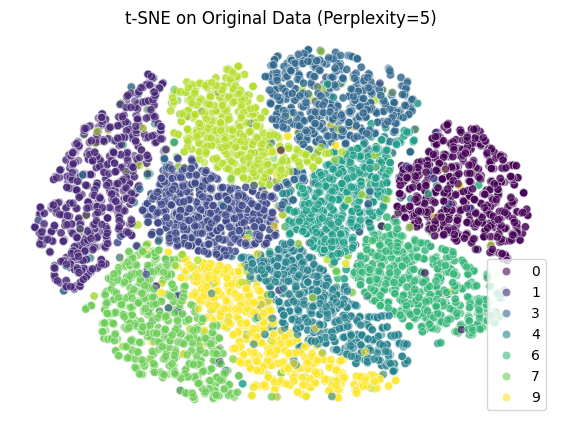

Computing t-SNE on original data with perplexity=30...


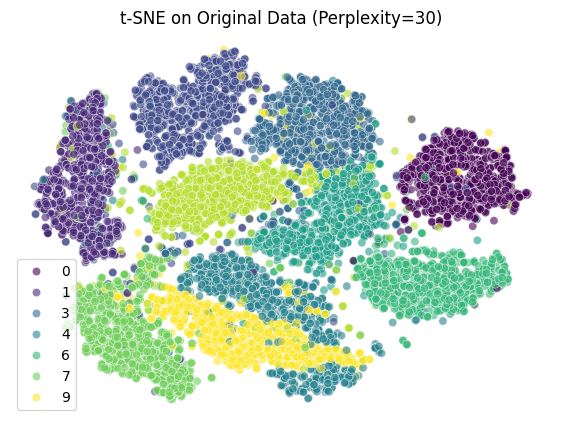

Computing t-SNE on PCA-reduced data (50 Dimensions) with perplexity=30...


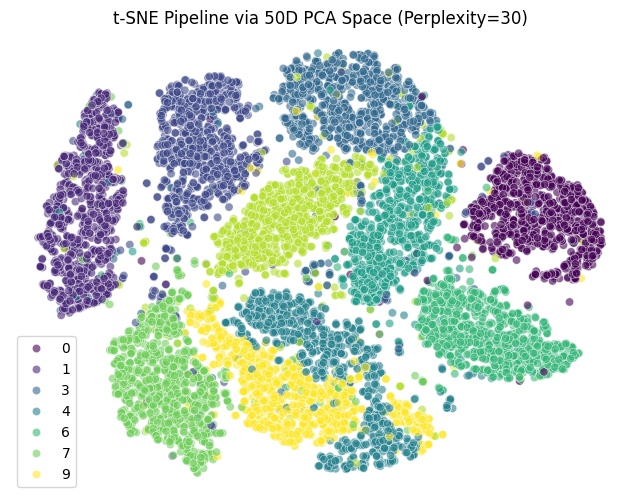

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

print("\n--- BLOCK C: t-SNE VISUALIZATION ---")

# # 1. Experiment with different perplexity parameters on original data
perplexities = [5, 30]

for perp in perplexities:
    print(f"Computing t-SNE on original data with perplexity={perp}...")
    # Changed n_iter to max_iter to resolve the FutureWarning
    tsne_orig = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=500)
    X_tsne_orig = tsne_orig.fit_transform(X_scaled)

    plt.figure(figsize=(7, 5))
    # Fixed indexing from letter 'O' to number '0', and changed palette 'jet' to 'viridis'
    sns.scatterplot(x=X_tsne_orig[:, 0], y=X_tsne_orig[:, 1], hue=y_sub, palette='viridis', alpha=0.6)
    plt.title(f"t-SNE on Original Data (Perplexity={perp})")
    plt.axis('off')
    plt.show()

# # 2. Optimize process by executing t-SNE directly on 50D PCA representations
print("Computing t-SNE on PCA-reduced data (50 Dimensions) with perplexity=30...")
# Changed n_iter to max_iter
tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
X_tsne_pca = tsne_pca.fit_transform(X_pca_50d)

plt.figure(figsize=(8, 6))
# Fixed indexing from letter 'O' to number '0', and changed palette 'jet' to 'viridis'
sns.scatterplot(x=X_tsne_pca[:, 0], y=X_tsne_pca[:, 1], hue=y_sub, palette='viridis', alpha=0.6)
plt.title("t-SNE Pipeline via 50D PCA Space (Perplexity=30)")
plt.axis('off')
plt.show()

